In [1]:
import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import os

In [5]:
test_file = Dataset('/mnt/ssd1/mbaldwin/12hr_genesis_labels/2020/gen_labels_12hr_expansion_2020083118.nc')

In [6]:
test_file

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    source: expanding genesis labels.ipynb
    institution: CIRA
    title: Temporally-expanded gridded genesis labels
    history:  Created 2022-07-13T22:49:33.775Z
    dimensions(sizes): latitude(91), longitude(360)
    variables(dimensions): float32 latitude(latitude), float32 longitude(longitude), float32 gen_label(latitude, longitude)
    groups: 

In [12]:
labels = test_file.variables['gen_label']

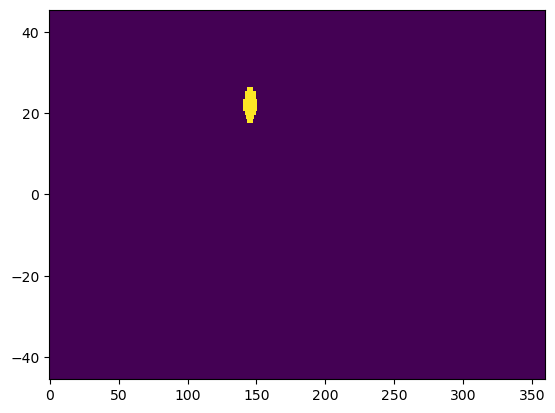

In [13]:
plt.pcolormesh(test_file.variables['longitude'],test_file.variables['latitude'],labels)

In [14]:
sst_test = Dataset('/mnt/tcnas08/cslocum/TCFPv4/devdat/v1p0/sst/1p00/2020/0831/TCFP-devdat-pred-sst_v4r0_blend_s202008310600000_e202008310600000_c202401232216040.nc')
sst_var = sst_test.variables['sea_surface_temperature']
#sst_test.variables['latitude'].shape

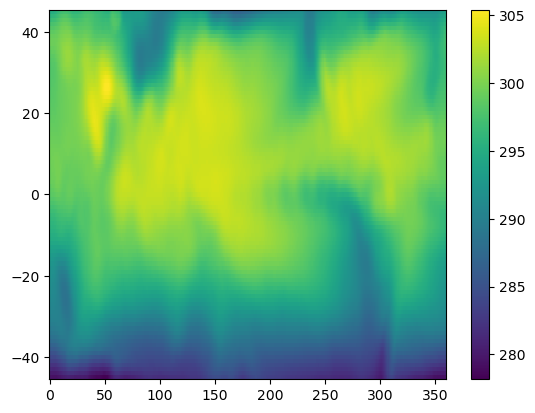

In [15]:
plt.pcolormesh(sst_test.variables['longitude'],sst_test.variables['latitude'],np.squeeze(sst_var[0,:,:]))
plt.colorbar()

In [16]:
fpath_main = '/mnt/tcnas08/cslocum/TCFPv4/devdat/v1p0/'
satellite_test = Dataset(fpath_main+'satellite/1p00/2020/0831/TCFP-devdat-pred-sat_v4r0_blend_s202008310600000_e202008310600000_c202401232313430.nc')
#print(satellite_test.variables)

In [17]:
tb_test = satellite_test.variables['brightness_temperature_clear']
pct_below = satellite_test.variables['percent_pixel_below_threshold']

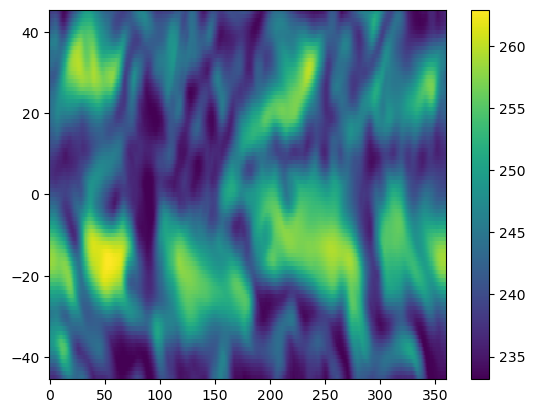

In [18]:
plt.pcolormesh(satellite_test.variables['longitude'],satellite_test.variables['latitude'],np.squeeze(tb_test[0,:,:]))
plt.colorbar()

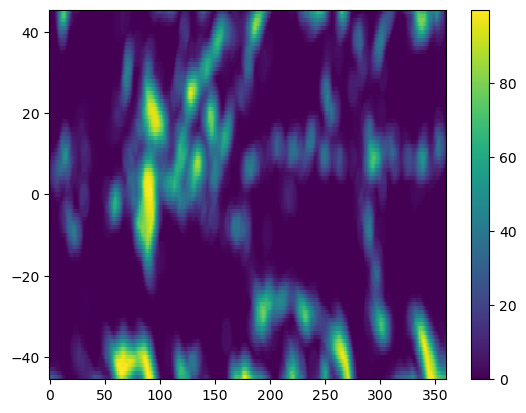

In [19]:
plt.pcolormesh(satellite_test.variables['longitude'],satellite_test.variables['latitude'],np.squeeze(pct_below[0,:,:]))
plt.colorbar()

In [20]:
storm_test = Dataset(fpath_main+'storm/1p00/2020/0831/TCFP-devdat-verif-storm_v4r0_blend_s202008310600000_e202008310600000_c202401250347110.nc')
storm_test.variables

{'time': <class 'netCDF4._netCDF4.Variable'>
 int64 time(time)
     long_name: Valid time of either the analysis or a forecast field
     standard_name: time
     units: hours since 1970-01-01T00:00:00Z
     calendar: standard
     axis: T
     coverage_content_type: coordinate
 unlimited dimensions: 
 current shape = (1,)
 filling on, default _FillValue of -9223372036854775806 used,
 'atcfid': <class 'netCDF4._netCDF4.Variable'>
 vlen atcfid(atcfid)
     long_name: Automated Tropical Cyclone Forecast system storm identification number
     standard_name: automated_tropical_cyclone_forecasting_system_storm_identifier
     calendar: standard
 vlen data type: <class 'str'>
 unlimited dimensions: 
 current shape = (4,),
 'latitude': <class 'netCDF4._netCDF4.Variable'>
 float32 latitude(latitude)
     long_name: Latitude
     standard_name: latitude
     units: degrees_north
     axis: Y
     valid_range: [-45.  45.]
 unlimited dimensions: 
 current shape = (91,)
 filling on, default _Fill

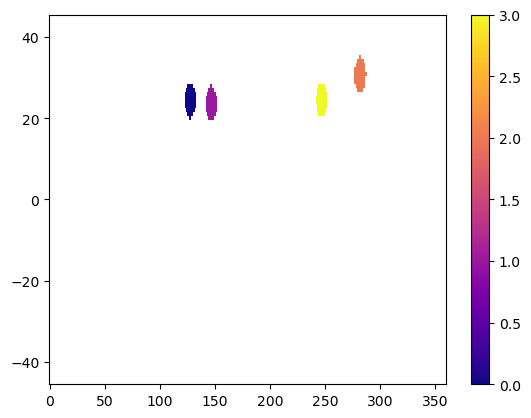

In [66]:
plt.pcolormesh(storm_test.variables['longitude'],storm_test.variables['latitude'],
               np.squeeze(storm_test.variables['storm_atcfid'][0,:,:]),cmap='plasma')
plt.colorbar()

In [75]:
model_test = Dataset(fpath_main+'model/1p00/2020/0831/TCFP-devdat-pred-model_v4r0_blend_s202008310600000_e202008310600000_c202401251756200.nc')
model_test.variables#['region'][8] 

{'time': <class 'netCDF4._netCDF4.Variable'>
 int64 time(time)
     long_name: Valid time of either the analysis or a forecast field
     standard_name: time
     units: hours since 1970-01-01T00:00:00Z
     calendar: standard
     axis: T
     coverage_content_type: coordinate
 unlimited dimensions: 
 current shape = (1,)
 filling on, default _FillValue of -9223372036854775806 used,
 'level': <class 'netCDF4._netCDF4.Variable'>
 float32 level(level)
     long_name: pressure level
     standard_name: air_pressure
     units: hPa
     axis: Z
     valid_range: [  50. 1000.]
 unlimited dimensions: 
 current shape = (13,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'latitude': <class 'netCDF4._netCDF4.Variable'>
 float32 latitude(latitude)
     long_name: latitude coordinate
     standard_name: latitude
     units: degrees_north
     axis: Y
     coverage_content_type: coordinate
     valid_range: [-45.  45.]
 unlimited dimensions: 
 current shape = (91,)
 filling on, 

In [76]:
model_test.variables['divergence'].shape

(1, 13, 91, 360, 15)

In [87]:
model_test.variables['region'][10]

masked_array(data=1000.,
             mask=False,
       fill_value=1e+20,
            dtype=float32)

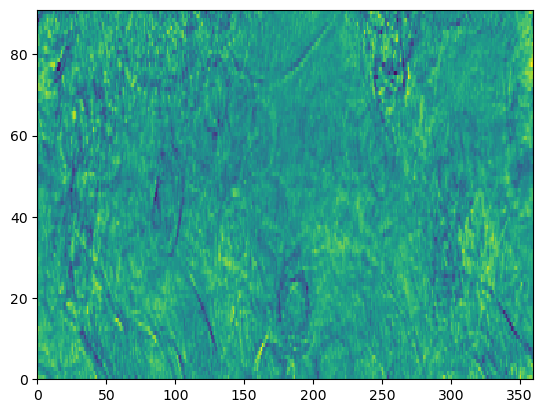

In [88]:
plt.pcolormesh(np.squeeze(model_test.variables['divergence'][0,10,:,:,10]))

In [93]:
derived_test = Dataset(fpath_main+'derived/1p00/2020/0831/TCFP-devdat-pred-deriv_v4r0_blend_s202008310600000_e202008310600000_c202401262140450.nc')
derived_test.variables#['level'][10]

{'time': <class 'netCDF4._netCDF4.Variable'>
 int64 time(time)
     long_name: Valid time of either the analysis or a forecast field
     standard_name: time
     units: hours since 1970-01-01T00:00:00Z
     calendar: standard
     axis: T
     coverage_content_type: coordinate
 unlimited dimensions: 
 current shape = (1,)
 filling on, default _FillValue of -9223372036854775806 used,
 'level': <class 'netCDF4._netCDF4.Variable'>
 float32 level(level)
     long_name: pressure level
     standard_name: air_pressure
     units: hPa
     axis: Z
     valid_range: [  50. 1000.]
 unlimited dimensions: 
 current shape = (13,)
 filling on, default _FillValue of 9.969209968386869e+36 used,
 'latitude': <class 'netCDF4._netCDF4.Variable'>
 float32 latitude(latitude)
     long_name: latitude coordinate
     standard_name: latitude
     units: degrees_north
     axis: Y
     coverage_content_type: coordinate
     valid_range: [-45.  45.]
 unlimited dimensions: 
 current shape = (91,)
 filling on, 

In [ ]:
plt.pcolormesh(np.squeeze(model_test.variables['divergence'][0,10,:,:,10]))